In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

import torch
import torch.nn as nn

from argparse import ArgumentParser
import yaml

import math
from torch import Tensor
from typing import List, Optional
from torch.optim.optimizer import Optimizer
from torch.utils.data import Dataset
from torch.utils import data

import torch.nn.functional as F

from torch.autograd import grad

from tqdm import tqdm

import scipy.io

import os

from timeit import default_timer

import matplotlib.pyplot as plt

try:
    import wandb
except ImportError:
    wandb = None

try:
    from pyDOE import lhs
    # Only needed for PINN's dataset
except ImportError:
    lhs = None

/var/folders/vf/j4qyq0p10yj4_5vlg2wvfjh00000gn/T/ipykernel_97110/3581623407.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
print(torch.__version__)

2.1.1


In [2]:
import jax.numpy as jnp
from jax import random, vmap, jit
from jax.experimental.ode import odeint
from jax import config

In [3]:
def RBF(x1, x2, params):
    outputscale, lengthscales = params
    diffs = jnp.expand_dims(x1 / lengthscales, 1) - \
            jnp.expand_dims(x2 / lengthscales, 0)
    r2 = jnp.sum(diffs**2, axis=2)
    return outputscale * jnp.exp(-0.5 * r2)

def GP_sample(key):
    N = 2048
    gp_params = (output_scale, length_scale)
    jitter = 1e-10
    X = jnp.linspace(0, tmax, N)[:,None]
    K = RBF(X, X, gp_params)
    L = jnp.linalg.cholesky(K + jitter*np.eye(N))
    gp_sample = jnp.dot(L, random.normal(key, (N,)))
    u_fn = lambda x : jnp.interp(x, X.flatten(), gp_sample)
    return u_fn

def generate_one_training_data(key, m=100):
    def odes(sigma_0,t):
        σ11,σ22,σ12 = sigma_0
        γd11 = 2*u_fn11(t)
        γd22 = 2*u_fn22(t)
        γd12 = (u_fn12(t) + u_fn21(t))
        ω12  = (u_fn12(t) - u_fn21(t))
        F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
        F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
        F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
        # The model differential equations
        du1 = η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ
        du2 = η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ
        du3 = η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ
        return [du1, du2, du3]
    key = random.split(key, 4)
    t = np.linspace(0, tmax, m)    
    u_fn12 = GP_sample(key[0])   
    u_fn21 = GP_sample(key[1])   
    u_fn11 = GP_sample(key[2])
    u_fn22 = GP_sample(key[3])
    sigma_0 = [0.0,0.0,0.0]
    σ11,σ22,σ12 = odeint(odes,sigma_0,t)
    v12 = vmap(u_fn12)(t)
    v21 = vmap(u_fn21)(t)
    v11 = vmap(u_fn11)(t)
    v22 = vmap(u_fn22)(t)
    u = jnp.stack([v12,v21,v11,v22,t],axis=-1)
    y = jnp.stack([σ11,σ22,σ12],axis=-1)
    return u, y
        
def generate_training_data(key, N, m):
    config.update("jax_enable_x64", True)
    keys = random.split(key, N)
    gen_fn = jit(lambda key: generate_one_training_data(key, m))
    u, y = vmap(gen_fn)(keys)
    u = jnp.float32(u)
    y = jnp.float32(y)
    config.update("jax_enable_x64", False)
    return u, y

In [10]:
η0, τ, α = 1.,1.,0.8
length_scale = 0.2
output_scale = 1.0
N_train = 1
m = 2**6
tmax = 2.0
batch_size=20
key_train = random.PRNGKey(0)
u_r_train, y_r_train = generate_training_data(key_train, N_train, m)

In [11]:
print(u_r_train.shape, y_r_train.shape)

(1, 64, 5) (1, 64, 3)


In [9]:
U_data = torch.from_numpy(np.array(u_r_train))
Y_data = torch.from_numpy(np.array(y_r_train))

TrainTestRatio = 0.8
ntrain = int(TrainTestRatio*U_data.shape[0])
ntest = int((1. - TrainTestRatio)*U_data.shape[0])
sub = 1

U_train = U_data[:ntrain,::sub,:]
Y_train = Y_data[:ntrain,::sub,:]
U_test = U_data[ntrain:,::sub,:]
Y_test = Y_data[ntrain:,::sub,:]

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(U_train,Y_train), batch_size=batch_size, shuffle=True)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [6]:
print(U_train.shape,Y_train.shape, U_test.shape, Y_test.shape)

torch.Size([8000, 64, 5]) torch.Size([8000, 64, 3]) torch.Size([2000, 64, 5]) torch.Size([2000, 64, 3])


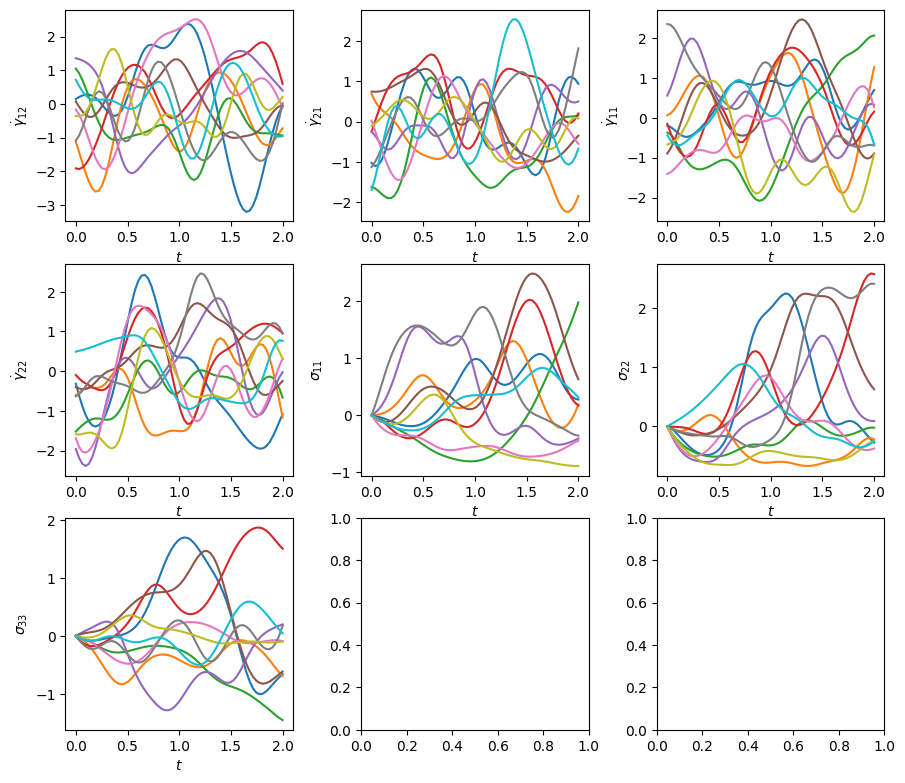

In [7]:
fig,axs=plt.subplots(3,3,figsize=(9,9))
ax = axs.flat
for i in range(10,20):
    ax[0].plot(U_data[i,:,4],U_data[i,:,0])
    ax[1].plot(U_data[i,:,4],U_data[i,:,1])
    ax[2].plot(U_data[i,:,4],U_data[i,:,2])
    ax[3].plot(U_data[i,:,4],U_data[i,:,3])
    ax[4].plot(U_data[i,:,4],Y_data[i,:,0])
    ax[5].plot(U_data[i,:,4],Y_data[i,:,1])
    ax[6].plot(U_data[i,:,4],Y_data[i,:,2])
ax[0].set_xlabel('$t$')
ax[0].set_ylabel('$\dot{\gamma}_{12}$')
ax[1].set_xlabel('$t$')
ax[1].set_ylabel('$\dot{\gamma}_{21}$')
ax[2].set_xlabel('$t$')
ax[2].set_ylabel('$\dot{\gamma}_{11}$')
ax[3].set_xlabel('$t$')
ax[3].set_ylabel('$\dot{\gamma}_{22}$')
ax[4].set_xlabel('$t$')
ax[4].set_ylabel('$\sigma_{11}$')
ax[5].set_xlabel('$t$')
ax[5].set_ylabel('$\sigma_{22}$')
ax[6].set_xlabel('$t$')
ax[6].set_ylabel('$\sigma_{33}$')
fig.subplots_adjust(left=0.04, bottom=0.15, right=0.95, top=0.95, wspace=0.3, hspace=0.2)
plt.show()

In [8]:
def add_padding(x, num_pad):
    if max(num_pad) > 0:
        res = F.pad(x, (num_pad[0], num_pad[1]), 'constant', 0)
    else:
        res = x
    return res


def add_padding2(x, num_pad1, num_pad2):
    if max(num_pad1) > 0 or max(num_pad2) > 0:
        res = F.pad(x, (num_pad2[0], num_pad2[1], num_pad1[0], num_pad1[1]), 'constant', 0.)
    else:
        res = x
    return res


def remove_padding(x, num_pad):
    if max(num_pad) > 0:
        res = x[..., num_pad[0]:-num_pad[1]]
    else:
        res = x
    return res


def remove_padding2(x, num_pad1, num_pad2):
    if max(num_pad1) > 0 or max(num_pad2) > 0:
        res = x[..., num_pad1[0]:-num_pad1[1], num_pad2[0]:-num_pad2[1]]
    else:
        res = x
    return res


def _get_act(act):
    if act == 'tanh':
        func = F.tanh
    elif act == 'gelu':
        func = F.gelu
    elif act == 'relu':
        func = F.relu_
    elif act == 'elu':
        func = F.elu_
    elif act == 'leaky_relu':
        func = F.leaky_relu_
    else:
        raise ValueError(f'{act} is not supported')
    return func

In [9]:
def save_checkpoint(path, name, model, optimizer=None):
    ckpt_dir = '%s/' % path
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir)
    try:
        model_state_dict = model.module.state_dict()
    except AttributeError:
        model_state_dict = model.state_dict()

    if optimizer is not None:
        optim_dict = optimizer.state_dict()
    else:
        optim_dict = 0.0

    torch.save({
        'model': model_state_dict,
        'optim': optim_dict
    }, ckpt_dir + name)



def save_ckpt(path, model, optimizer=None, scheduler=None):
    model_state = model.state_dict()
    if optimizer:
        optim_state = optimizer.state_dict()
    else:
        optim_state = None
    
    if scheduler:
        scheduler_state = scheduler.state_dict()
    else:
        scheduler_state = None
    torch.save({
        'model': model_state, 
        'optim': optim_state, 
        'scheduler': scheduler_state
    }, path)
    print(f'Checkpoint is saved to {path}')


In [10]:
class FNO1d(nn.Module):
    def __init__(self,
                 modes, width=32,
                 layers=None,
                 fc_dim=128,
                 in_dim=2, out_dim=1,
                 act='relu'):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains several layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .

        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        if layers is None:
            layers = [width] * 4

        self.fc0 = nn.Linear(in_dim, layers[0])  # input channel is 2: (a(x), x)

        self.sp_convs = nn.ModuleList([SpectralConv1d(
            in_size, out_size, num_modes) for in_size, out_size, num_modes in zip(layers, layers[1:], self.modes1)])

        self.ws = nn.ModuleList([nn.Conv1d(in_size, out_size, 1)
                                 for in_size, out_size in zip(layers, layers[1:])])

        self.fc1 = nn.Linear(layers[-1], fc_dim)
        self.fc2 = nn.Linear(fc_dim, out_dim)
        self.act = _get_act(act)

    def forward(self, x):
        length = len(self.ws)

        x = self.fc0(x)
        x = x.permute(0, 2, 1)

        for i, (speconv, w) in enumerate(zip(self.sp_convs, self.ws)):
            x1 = speconv(x)
            x2 = w(x)
            x = x1 + x2
            if i != length - 1:
                x = self.act(x)

        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

In [11]:
@torch.jit.script
def compl_mul1d(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
    res = torch.einsum("bix,iox->box", a, b)
    return res

In [12]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        # Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes1 = modes1

        self.scale = (1 / (in_channels*out_channels))
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfftn(x, dim=[2])

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.in_channels, x.size(-1)//2 + 1, device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes1] = compl_mul1d(x_ft[:, :, :self.modes1], self.weights1)

        # Return to physical space
        x = torch.fft.irfftn(out_ft, s=[x.size(-1)], dim=[2])
        return x


In [29]:
class LpLoss(object):
    '''
    loss function with rel/abs Lp loss
    '''
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = tmax / (x.size()[1] - 1.0)

        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)

        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)

In [14]:
class GIESEKUS_Loss(object):
    def __init__(self):
        super(GIESEKUS_Loss, self).__init__()

    def __call__(self,u,x,D=1):
        nt = u.size(1)   
        u_h = torch.fft.fft(u, dim=1)
        k_max = nt//2
        k_t = torch.cat((torch.arange(start=0, end=k_max, step=1, device=u.device),
                         torch.arange(start=-k_max, end=0, step=1, device=u.device)), 0).reshape(1,nt,1)
        ut_h = 2j *np.pi*k_t*u_h
        ut = torch.fft.irfft(ut_h[:, :k_max+1, :], dim=1, n=nt) * x[:,:,4:5] + u

        v12 = x[:,:,0:1]
        v21 = x[:,:,1:2]
        v11 = x[:,:,2:3]
        v22 = x[:,:,3:4]
        σ11 = u[:,:,0:1] * x[:,:,4:5]
        σ22 = u[:,:,1:2] * x[:,:,4:5]
        σ12 = u[:,:,2:3] * x[:,:,4:5]
        σ11_t = ut[:,:,0:1]
        σ22_t = ut[:,:,1:2]
        σ12_t = ut[:,:,2:3]
        γd11 = 2*v11
        γd22 = 2*v22
        γd12 = (v12 + v21)
        ω12  = (v12 - v21)
        F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
        F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
        F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
        # The model differential equations
        du1 = σ11_t - (η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ)
        du2 = σ22_t - (η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ)
        du3 = σ12_t - (η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ)
        f = torch.zeros(du1.shape, device=u.device)    
        loss_f1 = F.mse_loss(du1, f)
        loss_f2 = F.mse_loss(du2, f)
        loss_f3 = F.mse_loss(du3, f)        
        return loss_f1 + loss_f2  + loss_f3     

In [20]:
class PINO(object):
    def __init__(self,modes,width, in_dim=2, out_dim=1,lr=0.001,Tmax=100,loss_mode=None):
        super(PINO, self).__init__()
        self.model = FNO1d(modes, width, in_dim=in_dim, out_dim=out_dim)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=Tmax)
        self.loss_mode = loss_mode
        if(self.loss_mode is None):
            self.myloss = LpLoss(size_average=True)
        else:
            self.myloss = GIESEKUS_Loss()

    def train(self, train_loader, epochs):
        pbar = range(epochs)
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)
        for i in pbar:
            self.model.train()
            t1 = default_timer()
            train_l2 = 0
            for x, y in train_loader:
                self.optimizer.zero_grad()               
                out = self.model(x)
                if(self.loss_mode is None):
                    l2 = self.myloss(out.reshape(1, -1), y.reshape(1, -1))
                else:
                    l2 = self.myloss(out,x,D=tmax)
                l2.backward()
                self.optimizer.step()
                self.scheduler.step()
                train_l2 += l2.item()
            train_l2 /= N_train        
            t2 = default_timer()
            if i % 5 == 0:
                pbar.set_description((f'Epoch :{i}, time:{t2-t1}, Loss:{train_l2:.5f}'))
            if i % 20 == 0:
                save_checkpoint(save_dir,save_name.replace('.pt', f'_{i}.pt'), self.model, self.optimizer)
            save_checkpoint(save_dir,save_name, self.model, self.optimizer)

    def predict(self,x):
        if(self.loss_mode is None):
            return self.model(x)
        else:
            pred = self.model(x)
            pred[:,:,0:1]=pred[:,:,0:1] * x[:,:,4:5]
            pred[:,:,1:2]=pred[:,:,1:2] * x[:,:,4:5]
            pred[:,:,2:3]=pred[:,:,2:3] * x[:,:,4:5]
            return pred

    def load_ckpt(self,path):
        ckpt = torch.load(path)
        self.model.load_state_dict(ckpt['model'])

In [21]:
def plot(model):
    pred = model.predict(U_test).detach().numpy()
    time = U_test[:,:,4].detach().numpy()
    σ11_pred = pred[:,:,0]
    σ22_pred = pred[:,:,1]
    σ12_pred = pred[:,:,2]
    fig,ax=plt.subplots(1,3,figsize=(9,3))
    for i in range(10,20):
        ax[0].plot(time[i,:],Y_test[i,:,0])
        ax[0].plot(time[i,:],σ11_pred[i,:],'k--')
        ax[1].plot(time[i,:],Y_test[i,:,1])
        ax[1].plot(time[i,:],σ22_pred[i,:],'k--')
        ax[2].plot(time[i,:],Y_test[i,:,2])
        ax[2].plot(time[i,:],σ12_pred[i,:],'k--')        
    ax[0].set_xlabel('$t$')
    ax[0].set_ylabel('$\sigma_{11}$',labelpad=0)
    ax[1].set_xlabel('$t$')
    ax[1].set_ylabel('$\sigma_{22}$',labelpad=0)
    ax[2].set_xlabel('$t$')
    ax[2].set_ylabel('$\sigma_{12}$',labelpad=0)
    fig.subplots_adjust(left=0.07, bottom=0.15, right=0.99, top=0.95, wspace=0.3, hspace=0.2)
    plt.show()

In [22]:
learning_rate = 0.001
epochs = 100
iterations = epochs*(ntrain//batch_size)
modes = [15, 12, 9, 9]
width = 64

In [25]:
save_name='giesekus-eqn.pt'
save_dir='checkpoint_eq'
model = PINO(modes,width,in_dim=5,out_dim=3,lr=0.001,Tmax=iterations,loss_mode='Eq')
model.train(train_loader,epochs)

Epoch :85, time:8.65246133308392, Loss:0.00884:  86%|██████████████████████████████████████████████████████████████████▏          | 86/100 [12:33<02:02,  8.76s/it]


KeyboardInterrupt: 

In [27]:
model.train(train_loader,epochs)

Epoch :50, time:8.861247709020972, Loss:0.00977:  53%|████████████████████████████████████████▎                                   | 53/100 [08:05<07:10,  9.16s/it]


KeyboardInterrupt: 

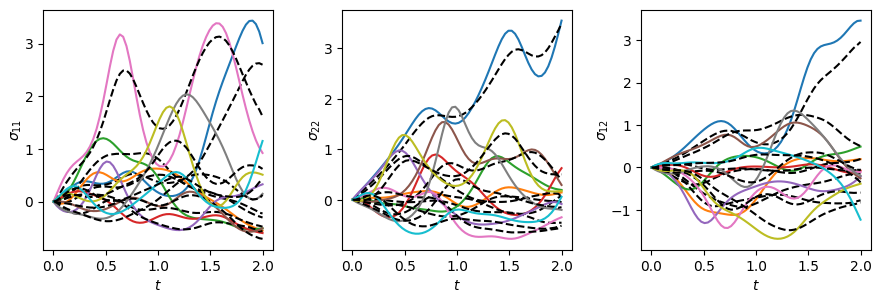

In [28]:
plot(model)

In [30]:
save_name='giesekus-data.pt'
save_dir='checkpoint_data'
model2 = PINO(modes,width,in_dim=5,out_dim=3,lr=0.001,Tmax=iterations,loss_mode=None)
model2.train(train_loader,epochs)

Epoch :40, time:8.598780957981944, Loss:0.00196:  45%|██████████████████████████████████▏                                         | 45/100 [06:34<08:01,  8.76s/it]


KeyboardInterrupt: 

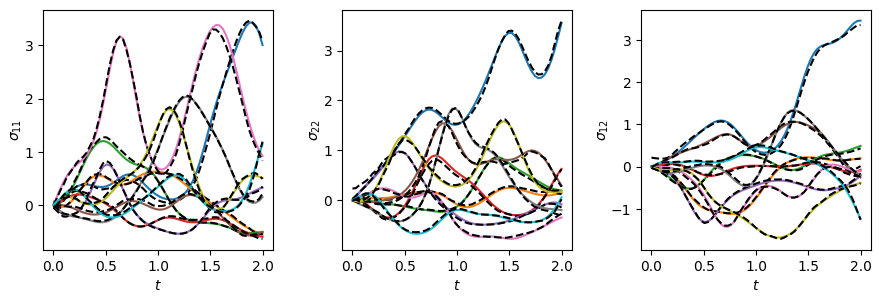

In [31]:
plot(model2)

In [ ]:
model3 = PINO(modes,width,in_dim=5,out_dim=3,lr=0.001,Tmax=iterations,loss_mode=None)
model3.load_ckpt('checkpoint_data/giesekus-data.pt')
plot(model3)

In [ ]:
model4 = PINO(modes,width,in_dim=5,out_dim=3,lr=0.001,Tmax=iterations,loss_mode='Eq')
model4.load_ckpt('checkpoint_eq/giesekus-eqn.pt')
plot(model4)